In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns #for the generation of corelation HeatMap

# LOADING THE DATA

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving DATASET - Sheet1.csv to DATASET - Sheet1 (1).csv


In [ ]:
# Load the data
df = pd.read_csv("DATASET - Sheet1.csv")

In [ ]:
#Display the first Five
df.head(5)

,CROP TYPE,SOIL TYPE,REGION,TEMPERATURE,WEATHER CONDITION,WATER REQUIREMENT
0,BANANA,DRY,DESERT,10-20,NORMAL,8.75
1,BANANA,DRY,DESERT,10-20,SUNNY,10.25
2,BANANA,DRY,DESERT,10-20,WINDY,9.65
3,BANANA,DRY,DESERT,10-20,RAINY,0.75
4,BANANA,DRY,DESERT,20-30,NORMAL,9.85


In [ ]:
#display the last five
df.tail(5)

,CROP TYPE,SOIL TYPE,REGION,TEMPERATURE,WEATHER CONDITION,WATER REQUIREMENT
2875,ONION,WET,HUMID,30-40,RAINY,0.100
2876,ONION,WET,HUMID,40-50,NORMAL,4.625
2877,ONION,WET,HUMID,40-50,SUNNY,6.125
2878,ONION,WET,HUMID,40-50,WINDY,5.625
2879,ONION,WET,HUMID,40-50,RAINY,0.200


In [ ]:
#To display water requirement
df['WATER REQUIREMENT']

,WATER REQUIREMENT
0,8.750
1,10.250
2,9.650
3,0.750
4,9.850
...,...
2875,0.100
2876,4.625
2877,6.125
2878,5.625


**Describing the data**

In [ ]:
#describe() method returns description of the data in the DataFrame.
df.describe()

,WATER REQUIREMENT
count,2880.000000
mean,6.463141
std,22.687385
min,0.100000
25%,2.700000
50%,5.860000
75%,8.000000
max,606.000000


In [ ]:
#To display number of rows and columns
df.shape

(2880, 6)

In [ ]:
'''Ye method aapke DataFrame ka overall structure batata hai — jaise ki ek quick report card

Total number of rows	Kitni entries/rows hain (like 4 rows)
Column names	Har column ka naam (like CROP TYPE, SOIL TYPE, etc.)
Non-null values	Har column mein kitne missing nahi hain values
Data types (dtype)	Kis type ka data hai — object, float64, int64, etc.
Memory usage	Kitna RAM use ho raha hai DataFrame ko store karne ke liye
RangeIndex	Row numbers ka range (jaise 0 to 3 for 4 rows)'''
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2880 entries, 0 to 2879
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CROP TYPE          2880 non-null   object 
 1   SOIL TYPE          2880 non-null   object 
 2   REGION             2880 non-null   object 
 3   TEMPERATURE        2880 non-null   object 
 4   WEATHER CONDITION  2880 non-null   object 
 5   WATER REQUIREMENT  2880 non-null   float64
dtypes: float64(1), object(5)
memory usage: 135.1+ KB


In [ ]:
#To return the number of unique values for each column
df.nunique()

,0
CROP TYPE,15
SOIL TYPE,3
REGION,4
TEMPERATURE,4
WEATHER CONDITION,4
WATER REQUIREMENT,436


# **DATA** **WRANGLING**
Raw data ko clean, organize karna

In [ ]:
#Ye method check karta hai har cell ke liye ki kya wo empty/missing hai ya nahi
#Agar data me koi missing value hai too usse "True" show hoga otherwise "False"
df.isna()

,CROP TYPE,SOIL TYPE,REGION,TEMPERATURE,WEATHER CONDITION,WATER REQUIREMENT
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
2875,False,False,False,False,False,False
2876,False,False,False,False,False,False
2877,False,False,False,False,False,False
2878,False,False,False,False,False,False


In [ ]:
#checking missing data
'''df.isnull() → Har cell ke liye check karta hai ki kya wo null/missing (NaN) hai?

Output: True ya False

.sum() → Har column ke liye True values ko count karta hai (True = 1)'''


df.isnull().sum()

# This indicates that there are no missing values

,0
CROP TYPE,0
SOIL TYPE,0
REGION,0
TEMPERATURE,0
WEATHER CONDITION,0
WATER REQUIREMENT,0


# Data Analysis

In [ ]:
#Relationship between weather condition and water requirement of each crop
my_numeric_df = df.select_dtypes(exclude='object')
my_object_df = df.select_dtypes(include='object')

In [ ]:
my_numeric_df

,WATER REQUIREMENT
0,8.750
1,10.250
2,9.650
3,0.750
4,9.850
...,...
2875,0.100
2876,4.625
2877,6.125
2878,5.625


In [ ]:
my_object_df

,CROP TYPE,SOIL TYPE,REGION,TEMPERATURE,WEATHER CONDITION
0,BANANA,DRY,DESERT,10-20,NORMAL
1,BANANA,DRY,DESERT,10-20,SUNNY
2,BANANA,DRY,DESERT,10-20,WINDY
3,BANANA,DRY,DESERT,10-20,RAINY
4,BANANA,DRY,DESERT,20-30,NORMAL
...,...,...,...,...,...
2875,ONION,WET,HUMID,30-40,RAINY
2876,ONION,WET,HUMID,40-50,NORMAL
2877,ONION,WET,HUMID,40-50,SUNNY
2878,ONION,WET,HUMID,40-50,WINDY


# one hot Encoding

In [ ]:
#"drop_first = True" Iska fayda yeh hota hai ki aap multicollinearity (overlapping information) se bach jaate ho.
df_object_dummies = pd.get_dummies(my_object_df, drop_first = True)

In [ ]:
#df_object_dummies → Ye aapka encoded categorical data hai jisme 0s aur 1s hain (after applying One Hot Encoding).
#.astype(int) → Ye data type ko integer (int) mein convert kar deta hai.
df_object_dummies = df_object_dummies.astype(int)
df_object_dummies

,CROP TYPE_BEAN,CROP TYPE_CABBAGE,CROP TYPE_CITRUS,CROP TYPE_COTTON,CROP TYPE_MAIZE,CROP TYPE_MELON,CROP TYPE_MUSTARD,CROP TYPE_ONION,CROP TYPE_POTATO,CROP TYPE_RICE,...,SOIL TYPE_WET,REGION_HUMID,REGION_SEMI ARID,REGION_SEMI HUMID,TEMPERATURE_20-30,TEMPERATURE_30-40,TEMPERATURE_40-50,WEATHER CONDITION_RAINY,WEATHER CONDITION_SUNNY,WEATHER CONDITION_WINDY
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2875,0,0,0,0,0,0,0,1,0,0,...,1,1,0,0,0,1,0,1,0,0
2876,0,0,0,0,0,0,0,1,0,0,...,1,1,0,0,0,0,1,0,0,0
2877,0,0,0,0,0,0,0,1,0,0,...,1,1,0,0,0,0,1,0,1,0
2878,0,0,0,0,0,0,0,1,0,0,...,1,1,0,0,0,0,1,0,0,1


In [ ]:
#Merging the two
#axis=1 ka matlab hai columns ko concatenate karna, agar axis=0 hota, toh wo rows ko merge karta.
final_df = pd.concat([my_numeric_df , df_object_dummies], axis = 1)

In [ ]:
final_df

,WATER REQUIREMENT,CROP TYPE_BEAN,CROP TYPE_CABBAGE,CROP TYPE_CITRUS,CROP TYPE_COTTON,CROP TYPE_MAIZE,CROP TYPE_MELON,CROP TYPE_MUSTARD,CROP TYPE_ONION,CROP TYPE_POTATO,...,SOIL TYPE_WET,REGION_HUMID,REGION_SEMI ARID,REGION_SEMI HUMID,TEMPERATURE_20-30,TEMPERATURE_30-40,TEMPERATURE_40-50,WEATHER CONDITION_RAINY,WEATHER CONDITION_SUNNY,WEATHER CONDITION_WINDY
0,8.750,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,10.250,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,9.650,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,0.750,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,9.850,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2875,0.100,0,0,0,0,0,0,0,1,0,...,1,1,0,0,0,1,0,1,0,0
2876,4.625,0,0,0,0,0,0,0,1,0,...,1,1,0,0,0,0,1,0,0,0
2877,6.125,0,0,0,0,0,0,0,1,0,...,1,1,0,0,0,0,1,0,1,0
2878,5.625,0,0,0,0,0,0,0,1,0,...,1,1,0,0,0,0,1,0,0,1


In [ ]:
#we can calcluate corelation
'''Ye function aapke DataFrame final_df ke sare numeric columns ke beech correlation calculate karta hai.
Correlation batata hai ki kis feature ka doosre feature ke saath relationship kya hai.

Correlation ka range -1 se +1 tak hota hai:

+1: Perfect positive correlation (jaise ek feature badhe toh doosra bhi badhe)

-1: Perfect negative correlation (jaise ek feature badhe toh doosra ghate)

0: No correlation (koi relationship nahi)'''

final_df.corr()['WATER REQUIREMENT'].sort_values()

,WATER REQUIREMENT
WEATHER CONDITION_RAINY,-0.138929
REGION_HUMID,-0.053149
SOIL TYPE_HUMID,-0.031930
TEMPERATURE_20-30,-0.031698
CROP TYPE_ONION,-0.030819
REGION_SEMI HUMID,-0.029359
CROP TYPE_CABBAGE,-0.024198
CROP TYPE_CITRUS,-0.024188
CROP TYPE_SOYABEAN,-0.014845
CROP TYPE_BEAN,-0.014845


# corelation

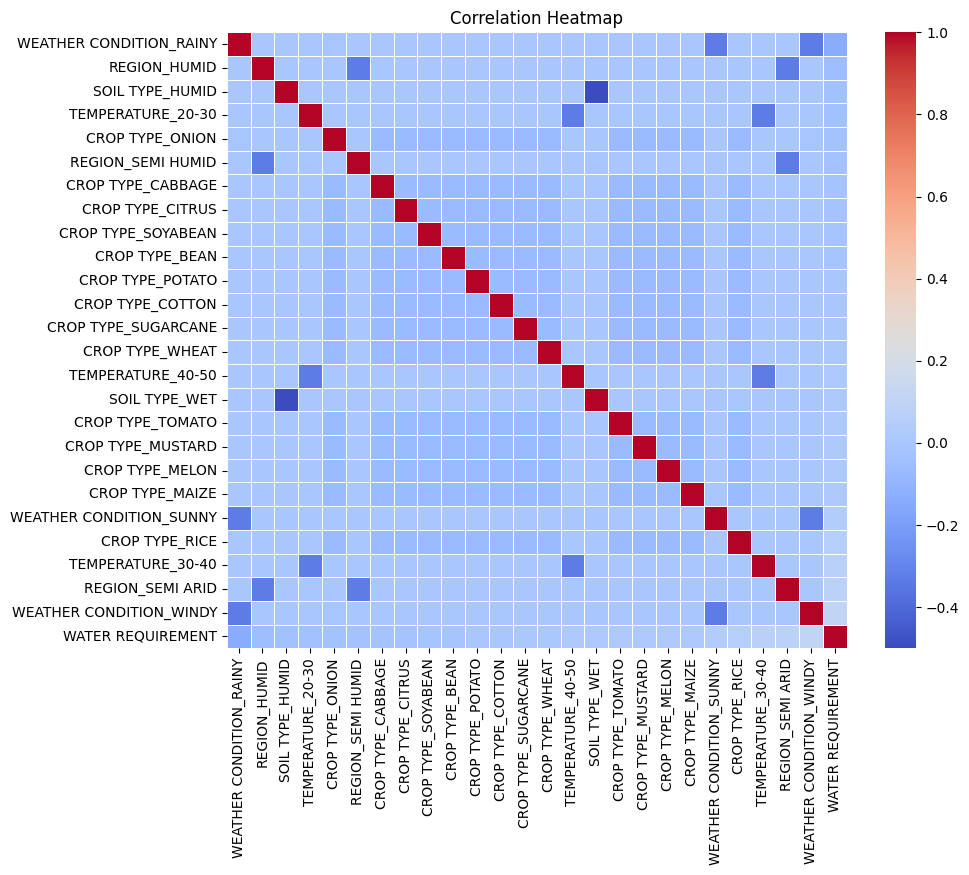

In [ ]:
correlation_matrix = final_df.corr()

# Sort the correlation values with respect to 'WATER REQUIREMENT'
sorted_correlation = correlation_matrix['WATER REQUIREMENT'].sort_values()

# Create a subset of the correlation matrix with the sorted columns
#.loc[sorted_correlation.index, sorted_correlation.index]   ka matlab hai ki aap sirf un columns aur rows ko select kar rahe ho jinke indexes sorted_correlation mein hain.
subset_corr_matrix = correlation_matrix.loc[sorted_correlation.index, sorted_correlation.index]

# Create a heatmap using Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(subset_corr_matrix, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

# The corelation of water requirement with other columns

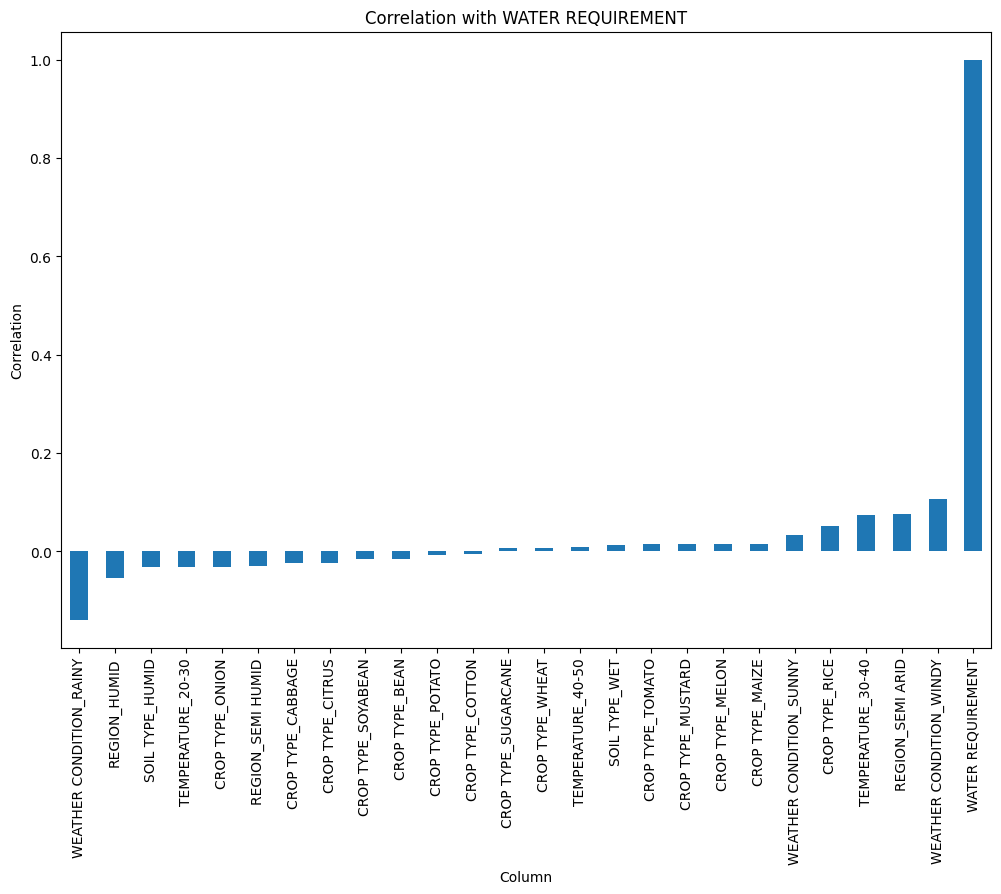

In [ ]:
#Calculate the correlation between 'WATER REQUIREMENT' and other columns
correlation_series = final_df.corr()['WATER REQUIREMENT'].sort_values()

# Creating a bar plot
plt.figure(figsize=(12, 8))
correlation_series.plot(kind='bar')
plt.title('Correlation with WATER REQUIREMENT')
plt.xlabel('Column')
plt.ylabel('Correlation')
plt.xticks(rotation=90)
plt.show()

# Split Data into Training and Testing

In [ ]:
# features (X) aur target (y) ko define kar rahe ho.
X = final_df.drop(columns=['WATER REQUIREMENT'])
#X ke andar ab saare wo columns honge jo input ke kaam aayenge, jaise: temperature, weather condition (one-hot encoded values), crop type, etc.
y = final_df['WATER REQUIREMENT']
#Aapne final_df ka 'WATER REQUIREMENT' column alag se y variable mein store kiya hai.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#random_state=42 →      Isse random splitting ko fix kiya jaata hai, taaki baar-baar run karne par same split mile. (Reproducibility)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, min_samples_leaf = 4,min_samples_split =10)

'''n_estimators=100	100 decision trees banenge forest ke andar. Zyada trees = stable aur accurate prediction.
min_samples_leaf=4	Har tree ka last node (leaf) tabhi banega jab usme kam se kam 4 data points ho.
min_samples_split=10	Koi bhi node tabhi split hoga jab usme at least 10 samples hon. Ye overfitting se bachata hai.'''

In [ ]:
model.fit(X_train, y_train)

RandomForestRegressor(min_samples_leaf=4, min_samples_split=10)

# Model Evaluation

In [ ]:
from sklearn.metrics import mean_squared_error,mean_absolute_error, r2_score

# Predictions
y_pred = model.predict(X_test)

# Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)
print(f'Mean Absolute Error (MAE): {mae}')

# Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error (MSE): {mse}')

# R-squared (R²) - Coefficient of determination
r2 = r2_score(y_test, y_pred)
print(f'R-squared (R²): {r2}')

Mean Absolute Error (MAE): 1.3881606871308338
Mean Squared Error (MSE): 22.889788106610904
R-squared (R²): -0.42845722911591366


In [ ]:
X.head()

,CROP TYPE_BEAN,CROP TYPE_CABBAGE,CROP TYPE_CITRUS,CROP TYPE_COTTON,CROP TYPE_MAIZE,CROP TYPE_MELON,CROP TYPE_MUSTARD,CROP TYPE_ONION,CROP TYPE_POTATO,CROP TYPE_RICE,...,SOIL TYPE_WET,REGION_HUMID,REGION_SEMI ARID,REGION_SEMI HUMID,TEMPERATURE_20-30,TEMPERATURE_30-40,TEMPERATURE_40-50,WEATHER CONDITION_RAINY,WEATHER CONDITION_SUNNY,WEATHER CONDITION_WINDY
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0


In [ ]:
y.head()

,WATER REQUIREMENT
0,8.75
1,10.25
2,9.65
3,0.75
4,9.85
